# Notebook status and evaluation note

This notebook is retained as a portfolio record of the original experiment. The workflow evaluates `test_loader` during training and uses test accuracy for checkpoint selection. Its stored metrics are therefore **historical development results**, not a final estimate from an untouched test set. A rigorous rerun should select checkpoints on a separate validation split and evaluate the test split once.

The original Google Colab and Google Drive paths are also retained and must be changed before running the notebook.


In [ ]:
# ================================================================
# 0. Install required libraries
# ================================================================
!pip install -q numpy pandas scikit-learn matplotlib seaborn \
torch torchvision qiskit qiskit-machine-learning qiskit-aer \
imbalanced-learn tqdm

# ================================================================
# 1. Imports & Setup (QISKIT-SAFE)
# ================================================================
import os, random, math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

# -------- QISKIT (V2 ONLY — VERY IMPORTANT) --------
from qiskit.circuit.library import zz_feature_map, real_amplitudes
from qiskit.primitives import StatevectorEstimator
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.connectors import TorchConnector

# -------- Metrics --------
from sklearn.metrics import classification_report, confusion_matrix


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 83.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 119.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 86.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 5.2 MB/s eta 0:00:00


In [ ]:
# 2. Reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [ ]:
# 3. Mount Google Drive & Load Dataset
from google.colab import drive
import zipfile

drive.mount('/content/drive')
zip_path = "/content/drive/MyDrive/chest_xray.zip"
extract_path = "/content/MyDrive/chest_xray"

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
print("Dataset ready at:", extract_path)



Mounted at /content/drive
Dataset ready at: /content/MyDrive/chest_xray


In [ ]:
# ================================================================
# 4. Merge train+test+val → Balance → 80–20 Split (ROBUST)
# ================================================================
import shutil
from sklearn.model_selection import train_test_split

set_seed(42)

# --- FIND ACTUAL BASE DIRECTORY ---
base = extract_path

# Handle nested extraction like chest_xray/chest_xray
if os.path.isdir(os.path.join(base, "chest_xray")):
    base = os.path.join(base, "chest_xray")

print(" Using base dataset path:", base)

# Detect correct class folder names automatically
def find_class_dir(parent, class_name):
    for d in os.listdir(parent):
        if d.lower() == class_name.lower():
            return os.path.join(parent, d)
    raise FileNotFoundError(f"{class_name} not found in {parent}")

normal_dirs = []
pneumonia_dirs = []

for split in ["train", "test", "val"]:
    split_path = os.path.join(base, split)
    normal_dirs.append(find_class_dir(split_path, "normal"))
    pneumonia_dirs.append(find_class_dir(split_path, "pneumonia"))

# Collect image paths
normal_imgs = []
for d in normal_dirs:
    normal_imgs += [os.path.join(d, f) for f in os.listdir(d)]

pneumonia_imgs = []
for d in pneumonia_dirs:
    pneumonia_imgs += [os.path.join(d, f) for f in os.listdir(d)]

print("Original counts → Normal:", len(normal_imgs),
      "Pneumonia:", len(pneumonia_imgs))

# ------------------ BALANCING ------------------
pneumonia_imgs = random.sample(pneumonia_imgs, len(normal_imgs))

# ------------------ SPLIT ------------------
norm_train, norm_test = train_test_split(
    normal_imgs, test_size=0.2, random_state=42)

pneu_train, pneu_test = train_test_split(
    pneumonia_imgs, test_size=0.2, random_state=42)

# Output folders
balanced_base = "/content/balanced_chest_xray"
train_dir = f"{balanced_base}/train"
test_dir  = f"{balanced_base}/test"

for cls in ["NORMAL", "PNEUMONIA"]:
    os.makedirs(f"{train_dir}/{cls}", exist_ok=True)
    os.makedirs(f"{test_dir}/{cls}", exist_ok=True)

def copy_files(files, dst):
    for f in files:
        shutil.copy(f, dst)

copy_files(norm_train, f"{train_dir}/NORMAL")
copy_files(norm_test,  f"{test_dir}/NORMAL")
copy_files(pneu_train, f"{train_dir}/PNEUMONIA")
copy_files(pneu_test,  f"{test_dir}/PNEUMONIA")

print("Balanced dataset created ")
print("Train → Normal:", len(norm_train), "Pneumonia:", len(pneu_train))
print("Test  → Normal:", len(norm_test),  "Pneumonia:", len(pneu_test))


✅ Using base dataset path: /content/MyDrive/chest_xray/chest_xray
Original counts → Normal: 1583 Pneumonia: 4273
Balanced dataset created ✅
Train → Normal: 1266 Pneumonia: 1266
Test  → Normal: 317 Pneumonia: 317


In [ ]:
# ================================================================
# 5. Load Images into Memory (Balanced Dataset)
# ================================================================
img_size = (224, 224)

def load_images_from_folder(folder, label, target_size=img_size):
    data, labels = [], []
    for fname in os.listdir(folder):
        path = os.path.join(folder, fname)
        try:
            img = Image.open(path).convert("RGB").resize(target_size)
            data.append(np.array(img))
            labels.append(label)
        except:
            pass
    return data, labels

train_norm, y1 = load_images_from_folder(
    "/content/balanced_chest_xray/train/NORMAL", 0)
train_pneu, y2 = load_images_from_folder(
    "/content/balanced_chest_xray/train/PNEUMONIA", 1)

X_train = np.array(train_norm + train_pneu)
y_train = np.array(y1 + y2)

test_norm, y1t = load_images_from_folder(
    "/content/balanced_chest_xray/test/NORMAL", 0)
test_pneu, y2t = load_images_from_folder(
    "/content/balanced_chest_xray/test/PNEUMONIA", 1)

X_test = np.array(test_norm + test_pneu)
y_test = np.array(y1t + y2t)

print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (2532, 224, 224, 3) Test: (634, 224, 224, 3)


In [ ]:
#optional (sanity check)

from collections import Counter

print("Train distribution:", Counter(y_train))
print("Test distribution :", Counter(y_test))

assert Counter(y_train)[0] == Counter(y_train)[1], "Train set NOT balanced!"
assert Counter(y_test)[0] == Counter(y_test)[1], "Test set NOT balanced!"

print(" Sanity check passed: datasets are balanced")


Train distribution: Counter({np.int64(0): 1266, np.int64(1): 1266})
Test distribution : Counter({np.int64(0): 317, np.int64(1): 317})
✅ Sanity check passed: datasets are balanced


In [ ]:
# 5.1 . Dataset Class & DataLoaders
class ImageDataset(Dataset):
    def __init__(self, X, y, train=True):
        self.X = X
        self.y = y
        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.RandomResizedCrop(224, scale=(0.8, 1.0)) if train else transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip() if train else transforms.Lambda(lambda x: x),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ])

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img = self.X[idx]
        label = self.y[idx]
        img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.long)

train_loader = DataLoader(ImageDataset(X_train, y_train, train=True), batch_size=16, shuffle=True)
test_loader = DataLoader(ImageDataset(X_test, y_test, train=False), batch_size=16, shuffle=False)

In [ ]:
# ================================================================
# 6. Define Models (Baseline + Quantum) — QISKIT V2 SAFE
# ================================================================

from qiskit.circuit.library import zz_feature_map, real_amplitudes
from qiskit.primitives import StatevectorEstimator
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.connectors import TorchConnector
from qiskit.quantum_info import SparsePauliOp


class BaselineResNet(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        in_ftrs = self.model.fc.in_features
        self.model.fc = nn.Linear(in_ftrs, num_classes)

    def forward(self, x):
        return self.model(x)


def create_qnn(num_qubits=4, reps=2):
    feature_map = zz_feature_map(num_qubits, reps=reps)
    ansatz = real_amplitudes(num_qubits, reps=reps)
    qc = feature_map.compose(ansatz)

    estimator = StatevectorEstimator()

    observables = SparsePauliOp("Z" + "I" * (num_qubits - 1))

    qnn = EstimatorQNN(
        circuit=qc,
        estimator=estimator,
        input_params=feature_map.parameters,
        weight_params=ansatz.parameters,
        observables=observables
    )

    return TorchConnector(qnn)


class QuantumResNet(nn.Module):
    def __init__(self, num_classes=2, num_qubits=4, q_reps=2, proj_dim=8):
        super().__init__()

        self.resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.resnet.fc = nn.Identity()

        self.proj = nn.Linear(512, proj_dim)
        self.proj_norm = nn.LayerNorm(proj_dim)

        self.qnn = create_qnn(num_qubits=num_qubits, reps=q_reps)
        self.qnorm = nn.LayerNorm(1)

        self.fc = nn.Linear(512 + 1, num_classes)

    def forward(self, x):
        x_feat = self.resnet(x)
        q_in = torch.tanh(self.proj_norm(self.proj(x_feat)))
        q_out = self.qnorm(self.qnn(q_in))
        combined = torch.cat([x_feat, q_out], dim=1)
        return self.fc(combined)


In [ ]:
# 7. Optimizer + Training Utilities
def make_optimizer(model):
    q_params = [p for n, p in model.named_parameters() if 'qnn' in n or 'proj' in n]
    base_params = [p for n, p in model.named_parameters() if not any(k in n for k in ['qnn', 'proj'])]
    optimizer = torch.optim.AdamW([
        {'params': base_params, 'lr': 3e-4},
        {'params': q_params, 'lr': 1e-3},
    ], weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)
    return optimizer, scheduler

# 8. Evaluation + Confusion Matrix
def evaluate(model, dataloader, device, class_names=["NORMAL", "PNEUMONIA"]):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, preds = outputs.max(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    acc = 100 * np.mean(np.array(all_preds) == np.array(all_labels))
    print(f"\nTest Accuracy: {acc:.2f}%")
    print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.title(f"Confusion Matrix (Acc {acc:.2f}%)")
    plt.show()
    return acc

# 9. Train Function
def train_model(model, train_loader, test_loader, device, epochs=50, warmup_epochs=5, save_path=None):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer, scheduler = make_optimizer(model)
    best_acc = 0; hist = {"loss": [], "acc": [], "test_acc": []}

    if hasattr(model, "resnet"):
        print(f"\nWarm-up for {warmup_epochs} epochs...")
        for p in model.resnet.parameters(): p.requires_grad = False
        for ep in range(warmup_epochs):
            model.train(); run_loss = 0; correct = 0; total = 0
            for x, y in tqdm(train_loader, desc=f"Warmup {ep+1}/{warmup_epochs}"):
                x, y = x.to(device), y.to(device)
                optimizer.zero_grad()
                out = model(x); loss = criterion(out, y); loss.backward(); optimizer.step()
                run_loss += loss.item(); _, pred = out.max(1)
                correct += pred.eq(y).sum().item(); total += y.size(0)
            print(f"Warmup Epoch {ep+1}: Loss={run_loss/len(train_loader):.4f} Acc={100*correct/total:.2f}%")
        for p in model.resnet.parameters(): p.requires_grad = True

    print("\nFull Training...")
    for ep in range(epochs):
        model.train(); run_loss = 0; correct = 0; total = 0
        for x, y in tqdm(train_loader, desc=f"Epoch {ep+1}/{epochs}"):
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad(); out = model(x); loss = criterion(out, y); loss.backward(); optimizer.step()
            run_loss += loss.item(); _, pred = out.max(1)
            correct += pred.eq(y).sum().item(); total += y.size(0)
        scheduler.step()
        train_acc = 100 * correct / total
        test_acc = evaluate(model, test_loader, device)
        hist["loss"].append(run_loss/len(train_loader)); hist["acc"].append(train_acc); hist["test_acc"].append(test_acc)
        if test_acc > best_acc and save_path:
            best_acc = test_acc; torch.save(model.state_dict(), save_path)
            print(f"Saved best model ({best_acc:.2f}%)")
        print(f"Epoch {ep+1}: Loss={run_loss/len(train_loader):.4f}, TrainAcc={train_acc:.2f}%, TestAcc={test_acc:.2f}%")
    return hist, best_acc

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 180MB/s]



Warm-up for 3 epochs...


Warmup 1/3: 100%|██████████| 159/159 [04:07<00:00,  1.56s/it]


Warmup Epoch 1: Loss=0.5032 Acc=81.16%


...

Warmup Epoch 2: Loss=0.4152 Acc=87.84%


Warmup 3/3: 100%|██████████| 159/159 [04:06<00:00,  1.55s/it]


Warmup Epoch 3: Loss=0.3970 Acc=88.59%

Full Training...


Epoch 1/7: 100%|██████████| 159/159 [04:14<00:00,  1.60s/it]



Test Accuracy: 95.43%
              precision    recall  f1-score   support

      NORMAL     0.9390    0.9716    0.9550       317
   PNEUMONIA     0.9706    0.9369    0.9535       317

    accuracy                         0.9543       634
   macro avg     0.9548    0.9543    0.9542       634
weighted avg     0.9548    0.9543    0.9542       634



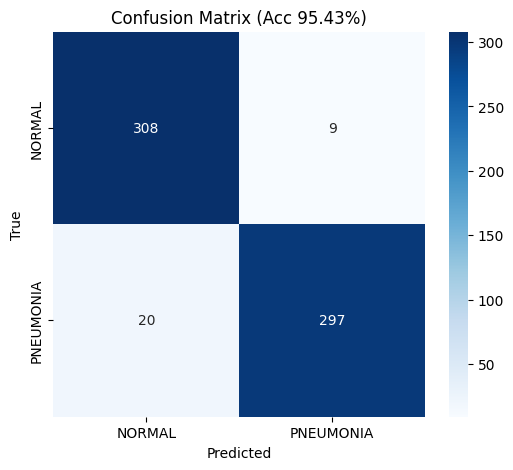

Saved best model (95.43%)
Epoch 1: Loss=0.3619, TrainAcc=91.55%, TestAcc=95.43%


Epoch 2/7: 100%|██████████| 159/159 [04:13<00:00,  1.59s/it]



Test Accuracy: 97.00%
              precision    recall  f1-score   support

      NORMAL     0.9627    0.9779    0.9703       317
   PNEUMONIA     0.9776    0.9621    0.9698       317

    accuracy                         0.9700       634
   macro avg     0.9701    0.9700    0.9700       634
weighted avg     0.9701    0.9700    0.9700       634



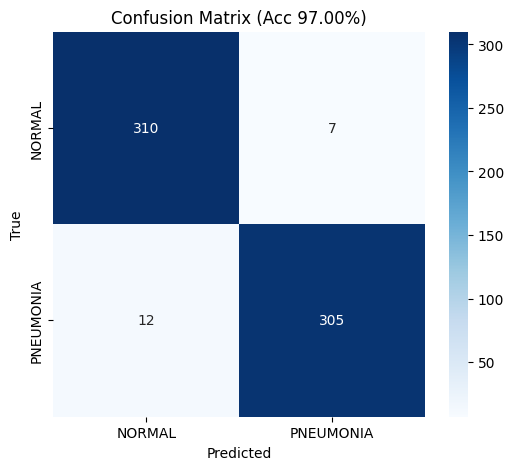

Saved best model (97.00%)
Epoch 2: Loss=0.2842, TrainAcc=95.22%, TestAcc=97.00%


Epoch 3/7: 100%|██████████| 159/159 [04:14<00:00,  1.60s/it]



Test Accuracy: 97.00%
              precision    recall  f1-score   support

      NORMAL     0.9715    0.9685    0.9700       317
   PNEUMONIA     0.9686    0.9716    0.9701       317

    accuracy                         0.9700       634
   macro avg     0.9700    0.9700    0.9700       634
weighted avg     0.9700    0.9700    0.9700       634



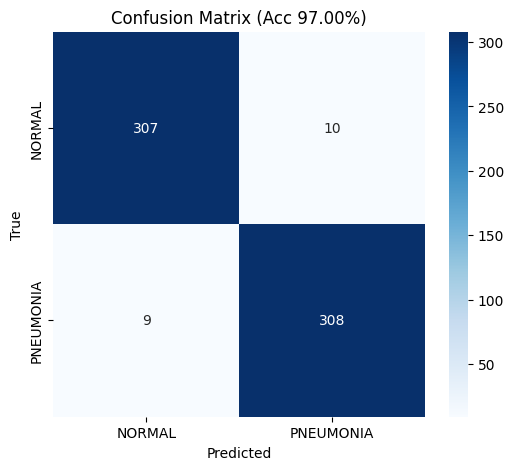

Epoch 3: Loss=0.2768, TrainAcc=95.70%, TestAcc=97.00%


Epoch 4/7: 100%|██████████| 159/159 [04:13<00:00,  1.60s/it]



Test Accuracy: 96.06%
              precision    recall  f1-score   support

      NORMAL     0.9424    0.9811    0.9614       317
   PNEUMONIA     0.9803    0.9401    0.9597       317

    accuracy                         0.9606       634
   macro avg     0.9613    0.9606    0.9606       634
weighted avg     0.9613    0.9606    0.9606       634



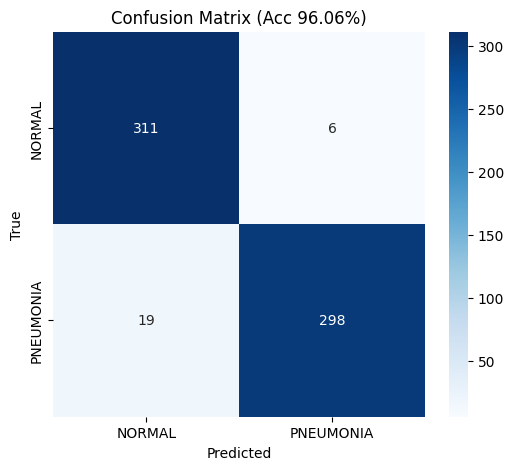

Epoch 4: Loss=0.2642, TrainAcc=96.88%, TestAcc=96.06%


Epoch 5/7: 100%|██████████| 159/159 [04:11<00:00,  1.58s/it]



Test Accuracy: 97.16%
              precision    recall  f1-score   support

      NORMAL     0.9746    0.9685    0.9715       317
   PNEUMONIA     0.9687    0.9748    0.9717       317

    accuracy                         0.9716       634
   macro avg     0.9716    0.9716    0.9716       634
weighted avg     0.9716    0.9716    0.9716       634



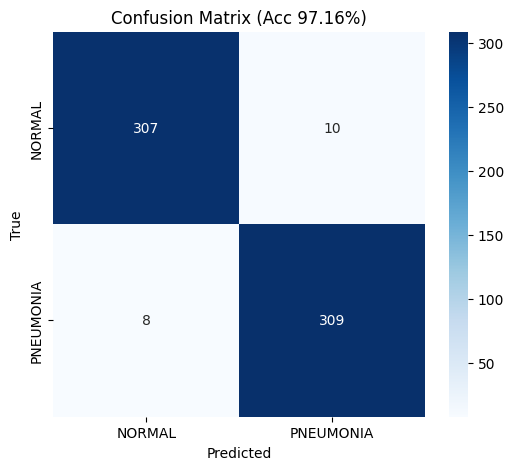

Saved best model (97.16%)
Epoch 5: Loss=0.2589, TrainAcc=96.84%, TestAcc=97.16%


Epoch 6/7: 100%|██████████| 159/159 [04:09<00:00,  1.57s/it]



Test Accuracy: 96.53%
              precision    recall  f1-score   support

      NORMAL     0.9868    0.9432    0.9645       317
   PNEUMONIA     0.9456    0.9874    0.9660       317

    accuracy                         0.9653       634
   macro avg     0.9662    0.9653    0.9653       634
weighted avg     0.9662    0.9653    0.9653       634



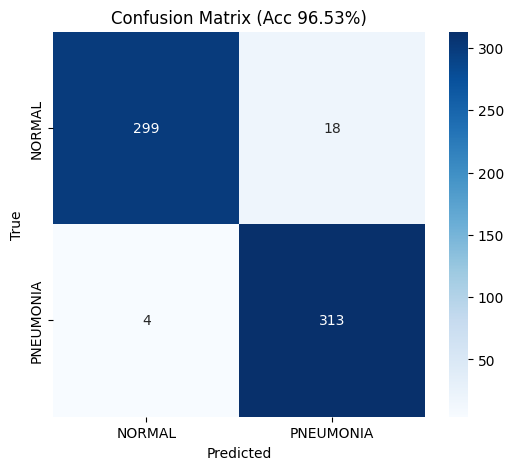

Epoch 6: Loss=0.2530, TrainAcc=96.88%, TestAcc=96.53%


Epoch 7/7: 100%|██████████| 159/159 [04:08<00:00,  1.56s/it]



Test Accuracy: 97.00%
              precision    recall  f1-score   support

      NORMAL     0.9967    0.9432    0.9692       317
   PNEUMONIA     0.9461    0.9968    0.9708       317

    accuracy                         0.9700       634
   macro avg     0.9714    0.9700    0.9700       634
weighted avg     0.9714    0.9700    0.9700       634



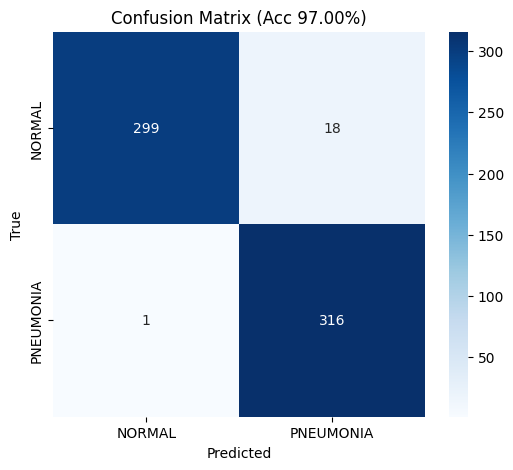

Epoch 7: Loss=0.2378, TrainAcc=97.99%, TestAcc=97.00%


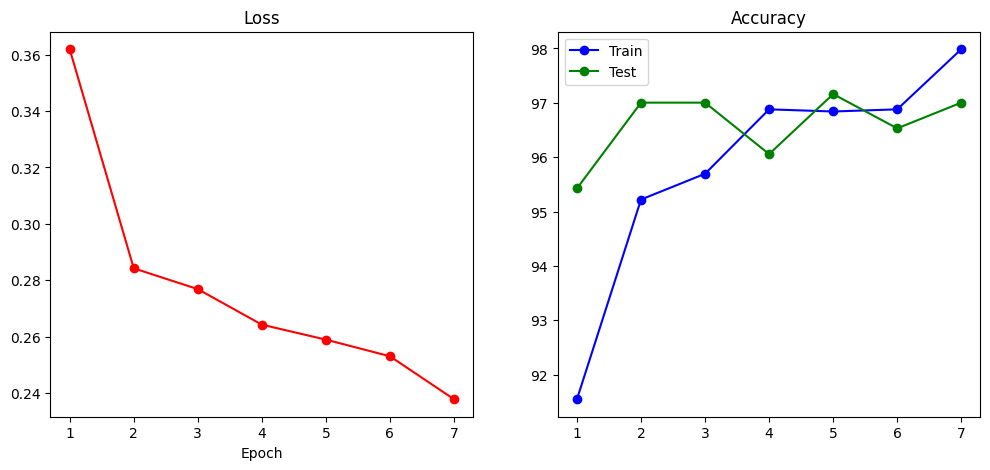

Quantum Hybrid Final Test Acc: 97.16088328075709


In [ ]:
def plot_training(hist):
    ep = range(1, len(hist["loss"]) + 1)
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1); plt.plot(ep, hist["loss"], 'r-o'); plt.title("Loss"); plt.xlabel("Epoch")
    plt.subplot(1, 2, 2); plt.plot(ep, hist["acc"], 'b-o', label="Train"); plt.plot(ep, hist["test_acc"], 'g-o', label="Test")
    plt.title("Accuracy"); plt.legend(); plt.show()

# 11. Train Quantum Hybrid ResNet
quantum_path = "/content/drive/MyDrive/best_quantum_512plus1_3w7e.pth"
q_model = QuantumResNet(num_classes=2, num_qubits=4, q_reps=2, proj_dim=4).to(device)
q_hist, q_acc = train_model(q_model, train_loader, test_loader, device, epochs=7, warmup_epochs=3, save_path=quantum_path)
plot_training(q_hist)
print("Quantum Hybrid Final Test Acc:", q_acc)